(1, 6)
(1, 21)
1.0


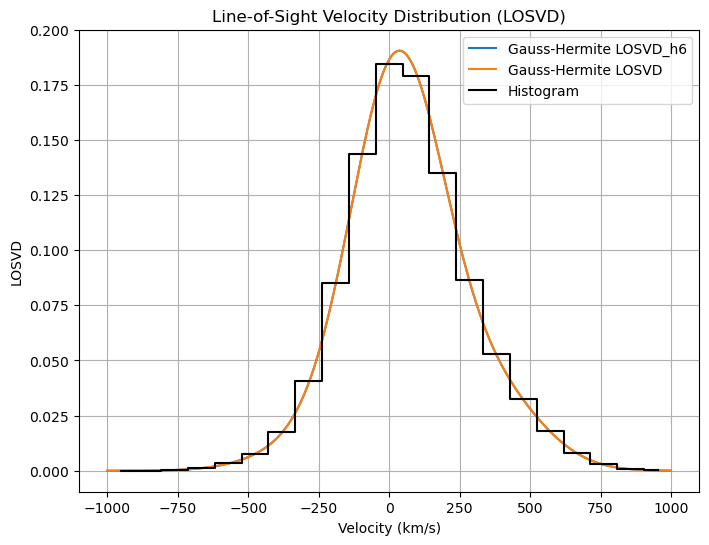

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from schwarzpy.gauss_hermite import gh_series, gh_series_h6, gh_hist_trapz, gh_hist, gh_hist_h6

# Define parameters
vel = 50.0       # Mean velocity
sigma = 200.0     # Velocity dispersion
h3 = 0.05        # Gauss-Hermite coefficient h3
h4 = 0.05      # Gauss-Hermite coefficient h4
h5 = 0.00       # Gauss-Hermite coefficient h5
h6 = -0.00      # Gauss-Hermite coefficient h6
# [-1.52243969e+03  3.56072064e+03  6.39877761e-01 -6.68979430e+00
#   -1.78796028e-01  1.66773113e-01]
nvbins = 21
vmax = 5 * sigma

# Define velocity range for plotting
x = np.linspace(-vmax, vmax, 500)

# Compute LOSVD using the Gauss-Hermite series expansion
losvd = gh_series_h6(x, vel, sigma, h3, h4, h5, h6)
losvd /= np.trapz(losvd, x)  # Normalize the LOSVD

# Plot the LOSVD
plt.figure(figsize=(8, 6))
plt.plot(x, losvd/nvbins*2*vmax, label='Gauss-Hermite LOSVD_h6')

losvd = gh_series(x, [vel, sigma, h3, h4, h5, h6])
losvd /= np.trapz(losvd, x)  # Normalize the LOSVD

plt.plot(x, losvd/nvbins*2*vmax, label='Gauss-Hermite LOSVD')


# Compute binned LOSVD
width = 1.6 *vmax/nvbins
bin_edges = np.linspace(-vmax, vmax, nvbins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

gh_data = np.array([[vel, sigma, h3, h4, h5, h6]])
print(gh_data.shape)

# bin_centers, losvd_binned = binned_gh_losvd(nbins, vmax, vel, sigma, h3, h4, h5, h6, oversample=1)
# plt.bar(bin_centers, losvd_binned, width=width, alpha=0.2, label='o=1')
# bin_centers, losvd_binned = binned_gh_losvd(nbins, vmax, vel, sigma, h3, h4, h5, h6, oversample=3)
# plt.bar(bin_centers, losvd_binned, width=width, alpha=0.2, color='b', label='o=3')
# losvd_binned = gh_hist_trapz(gh_data[0], nvbins, vmax, oversample=100)
# plt.bar(bin_centers, losvd_binned, width=width, alpha=0.2, color='r', label='o=100')
# print(np.sum(losvd_binned))

# hist = gh_hist_h6(gh_data, nvbins, vmax)
# print(hist.shape)
# plt.bar(bin_centers, hist[0], width=width, alpha=0.2, color='g', label='analytic_h6')
# print(np.sum(hist))

hist = gh_hist(gh_data, nvbins, vmax)
print(hist.shape)
plt.step(bin_centers, hist[0], color='k', label='Histogram', where='mid')
print(np.sum(hist))

plt.title('Line-of-Sight Velocity Distribution (LOSVD)')
plt.xlabel('Velocity (km/s)')
plt.ylabel('LOSVD')
plt.grid()
plt.legend()
plt.show()


(1000, 6)
(1, 21, 1000)


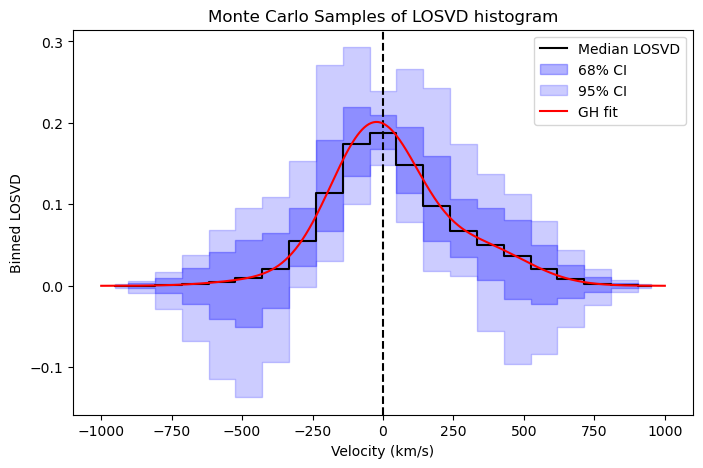

In [2]:
import numpy as np
import matplotlib.pyplot as plt

vel = 0.0       # Mean velocity
sigma = 200.0     # Velocity dispersion
h3 = 0.1        # Gauss-Hermite coefficient h3
h4 = 0.08      # Gauss-Hermite coefficient h4
h5 = 0.0       # Gauss-Hermite coefficient h5
h6 = 0.0      # Gauss-Hermite coefficient h6

dvel = 5.0
dsigma = 10.0
dh3 = 0.3
dh4 = 0.3
dh5 = 0.1
dh6 = 0.1

gh_data = np.array([[vel, sigma, h3, h4, h5, h6]])
dgh_data = np.array([[dvel, dsigma, dh3, dh4, dh5, dh6]])

from data_prep.hist_losvd import hist_mc, plot_hist_samples
from schwarzpy.gauss_hermite import gh_series

nvbins = 41
vmax = 5 * sigma
nmc = 1000

hist_samples = hist_mc(gh_data, dgh_data, nvbins, vmax, nmc)
print(hist_samples.shape)

bin_edges = np.linspace(-vmax, vmax, nvbins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
# hist_samples = np.clip(hist_samples, 0, None)  # Ensure no negative values
plot_hist_samples(hist_samples[0], bin_centers)

x = np.linspace(-vmax, vmax, 500)
losvd = gh_series(x, [vel, sigma, h3, h4, h5, h6])
plt.plot(x, losvd/nvbins*2*vmax, label='GH fit', color='r')
plt.legend()

vbin_id    v       dv    sigma    dsigma    h3   ... dh5  h6 dh6 is_good n_gh
------- -------- ------ -------- ------- ------- ... --- --- --- ------- ----
      1   8.2711 3.9083  282.083  5.2225 -0.0127 ... 0.1 0.0 0.1       1    6
      2    0.773 4.8005 283.8186  5.4771 -0.0284 ... 0.1 0.0 0.1       1    6
      3   6.1214  3.807 282.2219  5.1862  0.0085 ... 0.1 0.0 0.1       1    6
      4   7.6189 4.5628  284.477  5.2031  0.0051 ... 0.1 0.0 0.1       1    6
      5  -7.0427 3.9972  282.481  5.4509 -0.0167 ... 0.1 0.0 0.1       1    6
      6 -12.5076 4.1187 279.9931  4.5046 -0.0025 ... 0.1 0.0 0.1       1    6
      7   -2.823 4.3259 272.1632  5.8172   0.025 ... 0.1 0.0 0.1       1    6
      8   -5.748 3.4854  257.387  4.3457 -0.0033 ... 0.1 0.0 0.1       1    6
      9   0.6638 4.4012 277.8832  5.8103 -0.0031 ... 0.1 0.0 0.1       1    6
     10   4.9948 3.8319 268.5135  4.1612 -0.0185 ... 0.1 0.0 0.1       1    6
    ...      ...    ...      ...     ...     ... ... ... ... ...

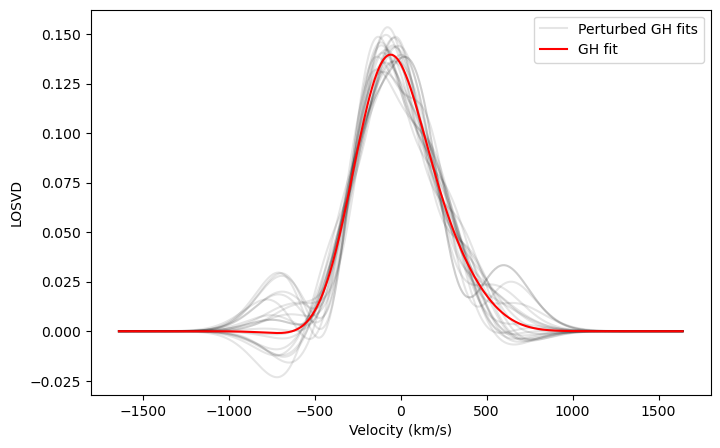

100%|██████████| 618/618 [00:19<00:00, 31.86it/s]


(618, 41, 2000)


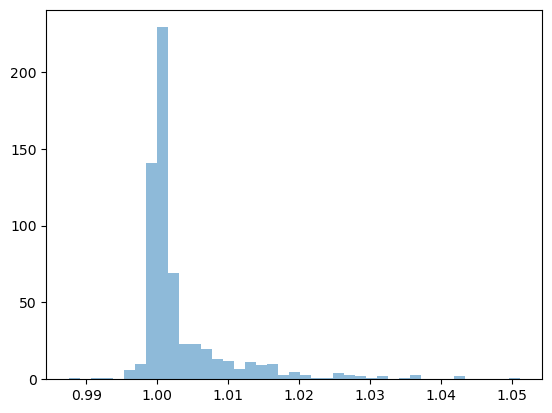

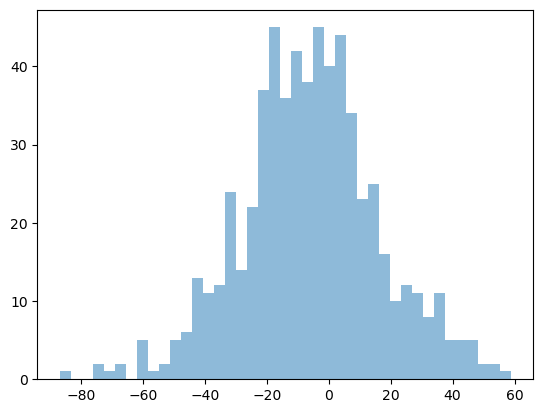

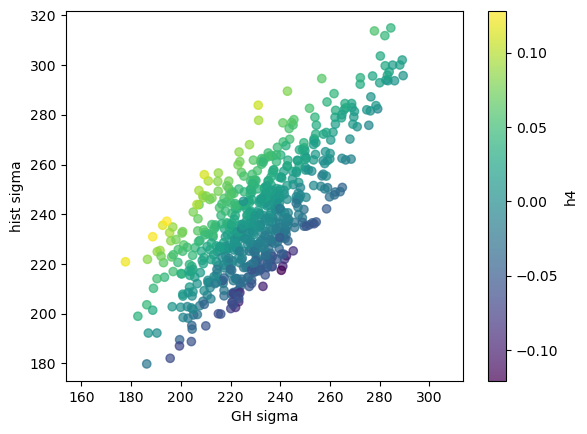

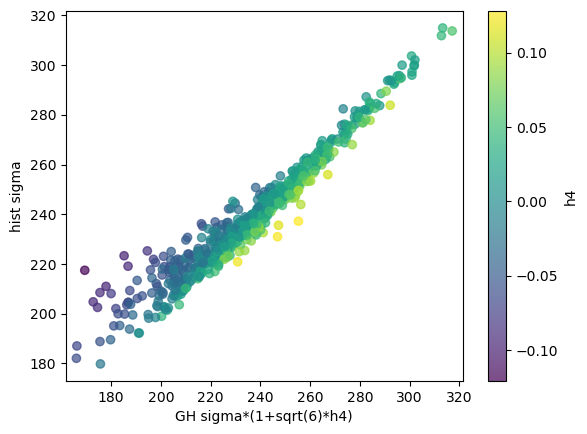

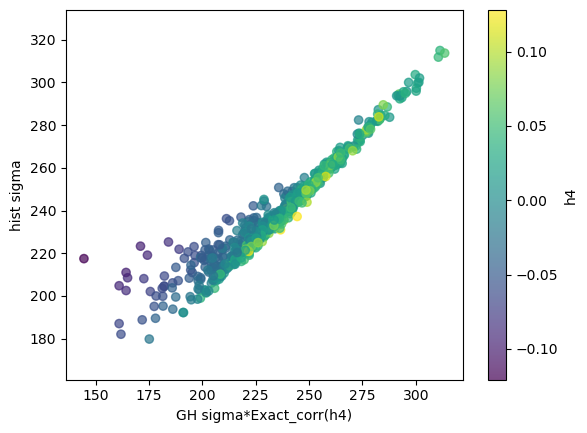

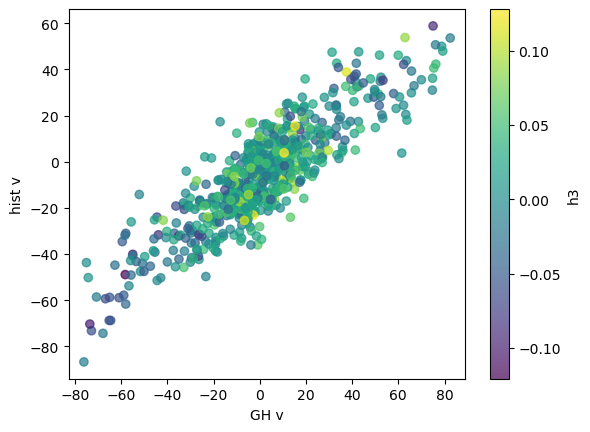

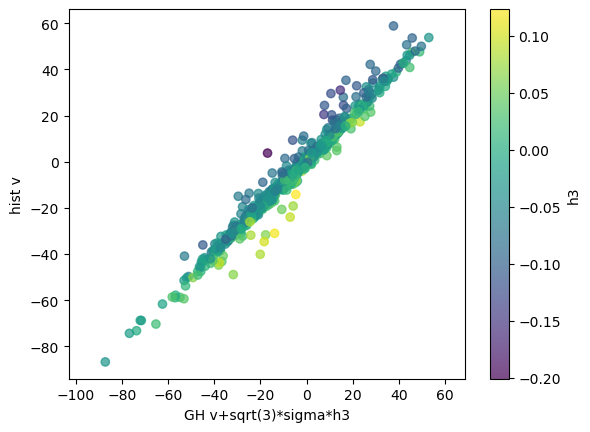

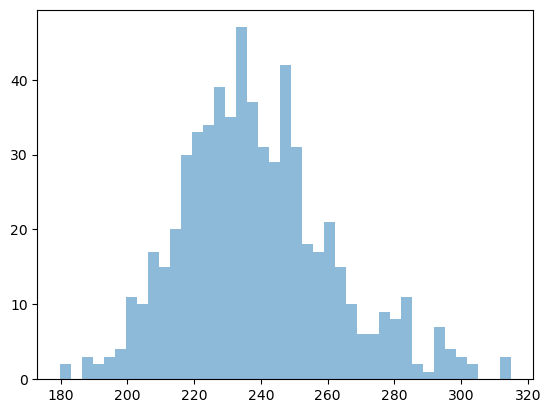

vbin_id    v       dv    sigma   dsigma   h3      dh3       h4       dh4      h5 dh5  h6 dh6 is_good n_gh
------- -------- ------ -------- ------ ------ ---------- ------ ----------- --- --- --- --- ------- ----
    101 -31.8534 4.6972 231.4817 6.8464 0.0743 0.02823556 0.0077 0.031744897 0.0 0.1 0.0 0.1       1    6


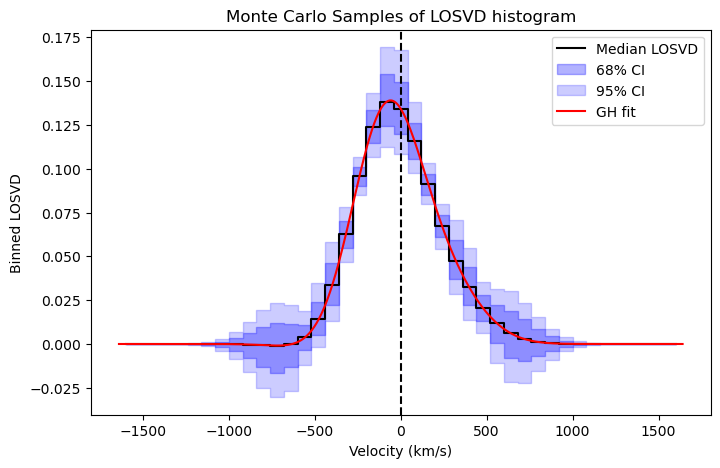

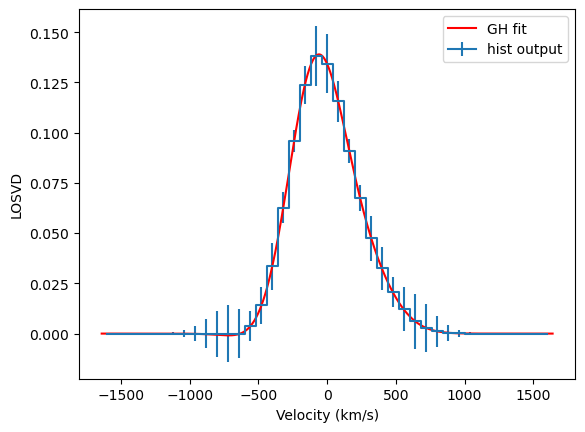

7.084793167740964
[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 3.73960078e-03 1.41413886e-02 3.34609887e-02
 6.25731076e-02 9.56204895e-02 1.23811335e-01 1.38208727e-01
 1.34220146e-01 1.15644761e-01 9.09898068e-02 6.74751578e-02
 4.74411296e-02 3.24734089e-02 2.07334084e-02 1.22247324e-02
 6.05540697e-03 2.65597763e-03 1.09251816e-03 3.41786685e-04
 5.84907866e-05 1.70720547e-05 2.95115510e-06 4.29357007e-07
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00]
9.819824797334475e-09
[4.87256371e-08 3.23841559e-07 1.89676276e-06 9.66476930e-06
 4.30551944e-05 1.62821498e-04 5.48150850e-04 1.53809429e-03
 3.64557481e-03 7.19235431e-03 1.14748676e-02 1.40986258e-02
 1.22598279e-02 7.29534910e-03 9.24193333e-03 1.17934732e-02
 7.77896488e-03 5.50732689e-03 9.38526676e-03 1.48800976e-02
 1.47077609e-02 1.02791765e-

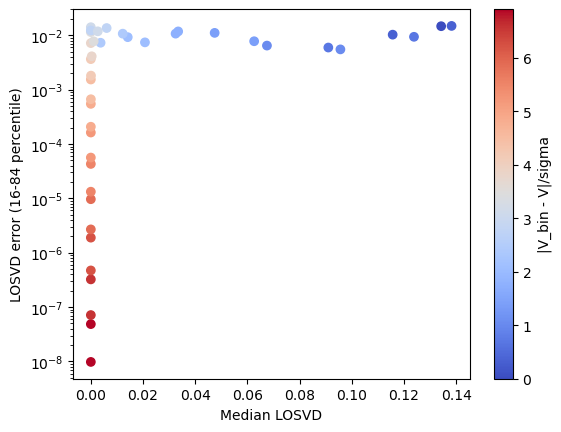

In [7]:
from astropy import table
from astropy.io import ascii
import matplotlib.pyplot as plt
import numpy as np

kinfile = './kinematics/gauss_hermite_kins_o.ecsv'
gh_table:table.Table = ascii.read(kinfile)
print(gh_table)

from data_prep.hist_losvd import hist_mc, plot_hist_samples
from schwarzpy.gauss_hermite import gh_series

nvbins = 41
vmax = 1640
nmc = 2000

# gh_table['sigma'] /= 1.5
gh_data = np.array([gh_table['v'],gh_table['sigma'],gh_table['h3'],gh_table['h4'],gh_table['h5'],gh_table['h6']]).T
dgh_data = np.array([gh_table['dv'],gh_table['dsigma'],gh_table['dh3'],gh_table['dh4'],gh_table['dh5'],gh_table['dh6']]).T
print(gh_data.shape)
print(dgh_data.shape)

ibin = 100#np.argmin(gh_table['v'])

M = 6
plt.figure(figsize=(8, 5))
pertu_gh = gh_data[ibin] + np.random.normal(size=(20, M)) * dgh_data[ibin]
for gh in pertu_gh:
    x = np.linspace(-vmax, vmax, 500)
    losvd = gh_series(x, gh)
    plt.plot(x, losvd/nvbins*2*vmax, alpha=0.1, color='k')
plt.plot(x, losvd/nvbins*2*vmax, alpha=0.1, color='k', label='Perturbed GH fits')
plt.plot(x, gh_series(x, gh_data[ibin])/nvbins*2*vmax, label='GH fit', color='r')
plt.legend()
plt.xlabel('Velocity (km/s)')
plt.ylabel('LOSVD')
plt.show()

hist_samples = hist_mc(gh_data, dgh_data, nvbins, vmax, nmc)

print(hist_samples.shape)

hist_median = np.median(hist_samples, axis=2)
hist_median = np.clip(hist_median, 0, None)  # Ensure no negative values

hist_l, hist_h = np.percentile(hist_samples, [16, 84], axis=2)
hist_err = 0.5 * (hist_h - hist_l)


# hist_std = np.std(hist_samples, axis=2)

# hist_median = hist_median/np.sum(hist_median, axis=1).reshape(-1, 1)

hist_sum = np.sum(hist_median, axis=1)

plt.hist(hist_sum, bins=nvbins, alpha=0.5, label='Median LOSVD')
plt.show()

bin_edges = np.linspace(-vmax, vmax, nvbins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

hist_v = np.sum(hist_median*bin_centers, axis=1) / hist_sum

plt.hist(hist_v, bins=nvbins, alpha=0.5, label='Median velocity')
plt.show()

hist_sigma = np.sqrt(np.sum(hist_median*bin_centers**2, axis=1) / hist_sum - hist_v**2)
plt.scatter(gh_table['sigma'], hist_sigma, c=gh_table['h4'], alpha=0.7)
plt.ylabel('hist sigma')
plt.xlabel('GH sigma')
plt.axis('equal')
plt.colorbar(label='h4')
plt.show()

sigma_corr = gh_table['sigma']*(1+np.sqrt(6)*gh_table['h4'])
sigma_corr1 = gh_table['sigma']*np.sqrt((1+2.25*np.sqrt(6)*gh_table['h4'])/(1+0.25*np.sqrt(6)*gh_table['h4']))
plt.scatter(sigma_corr, hist_sigma, c=gh_table['h4'], alpha=0.7)
plt.ylabel('hist sigma')
plt.xlabel('GH sigma*(1+sqrt(6)*h4)')
plt.axis('equal')
plt.colorbar(label='h4')
plt.show()

plt.scatter(sigma_corr1, hist_sigma, c=gh_table['h4'], alpha=0.7)
plt.ylabel('hist sigma')
plt.xlabel('GH sigma*Exact_corr(h4)')
plt.axis('equal')
plt.colorbar(label='h4')
plt.show()

plt.scatter(gh_table['v'], hist_v, c=gh_table['h4'], alpha=0.7)
plt.ylabel('hist v')
plt.xlabel('GH v')
plt.axis('equal')
plt.colorbar(label='h3')
plt.show()

v_corr = gh_table['v']+np.sqrt(3)*gh_table['sigma']*gh_table['h3']
plt.scatter(v_corr, hist_v, c=gh_table['h3'], alpha=0.7)
plt.ylabel('hist v')
plt.xlabel('GH v+sqrt(3)*sigma*h3')
plt.axis('equal')
plt.colorbar(label='h3')
plt.show()

# plt.scatter(sigma_corr1, sigma_corr1-sigma_corr, c=gh_table['h4'])
# plt.ylabel('hist sigma')
# plt.xlabel('GH sigma*(1+sqrt(6)*h4)')
# # plt.axis('equal')
# plt.colorbar(label='h4')
# plt.show()

plt.hist(hist_sigma, bins=nvbins, alpha=0.5, label='Median sigma')
plt.show()

# ibin = 0 #np.argmax(gh_table['h4'])#np.argmin(hist_sigma-sigma_corr1)#
print(gh_table[ibin])

plot_hist_samples(hist_samples[ibin], bin_centers)
x = np.linspace(-vmax, vmax, 500)
losvd = gh_series(x, gh_data[ibin])
losvd /= np.trapz(losvd, x)  # Normalize the LOSVD
plt.plot(x, losvd/nvbins*2*vmax, label='GH fit', color='r')
plt.legend()
plt.show()

plt.errorbar(bin_centers, hist_median[ibin], yerr=hist_err[ibin], fmt='-', label='hist output', drawstyle='steps-mid')

x = np.linspace(-vmax, vmax, 500)
losvd = gh_series(x, gh_data[ibin])
losvd /= np.trapz(losvd, x)  # Normalize the LOSVD
plt.plot(x, losvd/nvbins*2*vmax, label='GH fit', color='r')
plt.legend()
plt.xlabel('Velocity (km/s)')
plt.ylabel('LOSVD')
plt.show()

print(np.max(vmax/gh_table['sigma'][ibin]))
print(hist_median[ibin])
print(np.min(hist_err[ibin]))
print(hist_err[ibin])
plt.scatter(hist_median[ibin], hist_err[ibin], c=np.abs(bin_centers)/gh_table['sigma'][ibin], cmap='coolwarm')
plt.colorbar(label='|V_bin - V|/sigma')
plt.xlabel('Median LOSVD')
plt.ylabel('LOSVD error (16-84 percentile)')
plt.yscale('log')

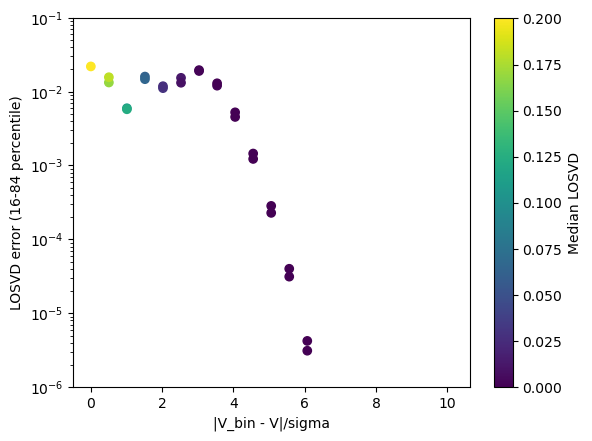

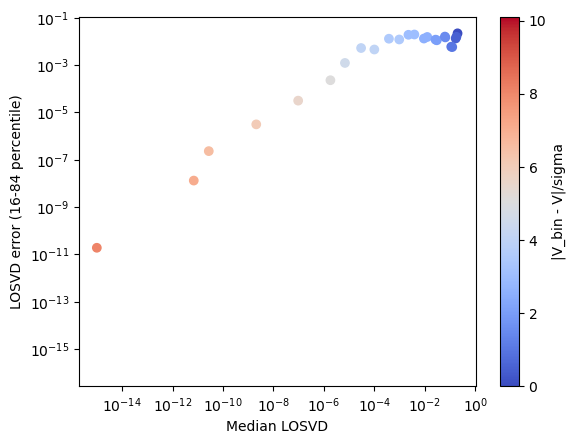

In [18]:
plt.scatter(np.abs(bin_centers)/gh_table['sigma'][ibin], hist_err[ibin], c=hist_median[ibin])
plt.colorbar(label='Median LOSVD')
plt.xlabel('|V_bin - V|/sigma')
plt.ylabel('LOSVD error (16-84 percentile)')
plt.yscale('log')
plt.ylim(1e-6, 1e-1)
plt.show()

plt.scatter(hist_median[ibin], hist_err[ibin], c=np.abs(bin_centers)/gh_table['sigma'][ibin], cmap='coolwarm')
plt.colorbar(label='|V_bin - V|/sigma')
plt.xlabel('Median LOSVD')
plt.ylabel('LOSVD error (16-84 percentile)')
plt.yscale('log')
plt.xscale('log')
plt.show()

In [1]:
from data_prep.hist_losvd import convert_gh_to_hist

kinfile = './kinematics/gauss_hermite_kins_o.ecsv'

nvbins = 21
vmax = 1000
nmc = 2000

hist_table = convert_gh_to_hist(kinfile, './kinematics/hist_kinematics.ecsv', nvbins, vmax, nmc)
print(hist_table)

100%|██████████| 618/618 [00:10<00:00, 59.07it/s]


Monte Carlo simulation completed. Computing median and uncertainties...
Histogram file saved in ./kinematics/hist_kinematics.ecsv
binID_dynamite    v      sigma   ...       dlosvd_20       is_good
-------------- -------- -------- ... --------------------- -------
             1   8.2711  282.083 ...  0.010105316190202912       1
             2    0.773 283.8186 ...  0.010457024179942334       1
             3   6.1214 282.2219 ...  0.010227434922263811       1
             4   7.6189  284.477 ...  0.010350023741015124       1
             5  -7.0427  282.481 ...   0.00978642276415513       1
             6 -12.5076 279.9931 ...   0.00896528482500694       1
             7   -2.823 272.1632 ...   0.00863894484755299       1
             8   -5.748  257.387 ...  0.006604229729280863       1
             9   0.6638 277.8832 ...  0.009607337517112824       1
            10   4.9948 268.5135 ...  0.008992817003215667       1
           ...      ...      ... ...                   ...     ...

In [5]:
m = np.array(((1,2),(3,4),(5,6)))
n = np.array((1,2))
print(n+m*n)

[[ 2  6]
 [ 4 10]
 [ 6 14]]
